# Notebook 03: Time Series Models (ARIMA & SARIMA)

**Project:** Forecasting Religious Tourism — ML Analysis of Pilgrimage Patterns to Sacred Sites in Nepal

**Purpose:** Train ARIMA and SARIMA models on each site's visitor data, generate forecasts, evaluate accuracy, and save models for later comparison.

**Input:** `../data/pilgrimage_data_clean.csv`

**Output:** Trained models saved as `.pkl` files in `../models/` folder

---

### What are ARIMA and SARIMA?

**ARIMA** (AutoRegressive Integrated Moving Average) learns patterns from the sequence of visitor numbers alone. It captures trends (are visitors increasing or decreasing over time?) but does not handle repeating seasonal cycles well.

**SARIMA** extends ARIMA by adding seasonal components. It captures both the trend AND the repeating 12-month seasonal pattern (e.g., Shivaratri peak every February, monsoon dip every July). For pilgrimage data with strong seasonal rhythms, SARIMA should outperform ARIMA.

Both models use only **two columns**: date and visitor count. They do not use weather, festivals, or any external features — that is what Random Forest and XGBoost handle in Notebook 04.

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

# Time series specific libraries
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller  # Stationarity test
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # Correlation plots

# For saving trained models
import joblib
import os

# For accuracy metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
warnings.filterwarnings('ignore')

# Create models folder if it does not exist
os.makedirs('../models', exist_ok=True)

print('Libraries imported successfully')

Libraries imported successfully


## Step 2: Load and Prepare Data

We load the cleaned data and convert it into a time series format that ARIMA and SARIMA require: a single column of visitor counts indexed by date.

In [2]:
# Load cleaned data
df = pd.read_csv('../data/pilgrimage_data_clean.csv')

# Convert date to datetime and set as index
df['date'] = pd.to_datetime(df['date'])

# List of sites
sites = sorted(df['site'].unique())
print(f'Sites: {sites}')
print(f'Date range: {df["date"].min()} to {df["date"].max()}')
print(f'Total rows: {len(df)}')

Sites: ['Janakpur Dham', 'Lumbini', 'Muktinath', 'Pashupatinath']
Date range: 2010-01-01 00:00:00 to 2025-12-01 00:00:00
Total rows: 756


## Step 3: Train-Test Split

For time series, we **cannot** do random splitting because the order matters. We use a **time-based split**: train on 2010-2022 data, test on 2023-2025 data. This way the model learns from the past and is tested on the future it has never seen.

In [3]:
# Define the split point
TRAIN_END = '2022-12'
TEST_START = '2023-01'

print(f'Training period: 2010-01 to {TRAIN_END}')
print(f'Testing period:  {TEST_START} to 2025-12')
print(f'Training months: ~156 months (13 years)')
print(f'Testing months:  ~36 months (3 years)')

Training period: 2010-01 to 2022-12
Testing period:  2023-01 to 2025-12
Training months: ~156 months (13 years)
Testing months:  ~36 months (3 years)


## Step 4: Check Stationarity

ARIMA requires the data to be **stationary** (no trend, constant variance over time). We use the **Augmented Dickey-Fuller (ADF) test** to check this. If the p-value is less than 0.05, the data is stationary. If not, we need to difference it.

In [4]:
def check_stationarity(series, site_name):
    """Run ADF test and print results"""
    result = adfuller(series.dropna())
    p_value = result[1]
    is_stationary = p_value < 0.05
    
    print(f'{site_name}:')
    print(f'  ADF Statistic: {result[0]:.4f}')
    print(f'  p-value: {p_value:.4f}')
    print(f'  Stationary: {"YES" if is_stationary else "NO — needs differencing"}')
    print()
    return is_stationary

# Test stationarity for each site
print('STATIONARITY TEST (ADF)')
print('=' * 50)
for site in sites:
    site_data = df[df['site'] == site].sort_values('date')
    check_stationarity(site_data['total_visitors'], site)

STATIONARITY TEST (ADF)
Janakpur Dham:
  ADF Statistic: -1.3382
  p-value: 0.6115
  Stationary: NO — needs differencing

Lumbini:
  ADF Statistic: -2.4337
  p-value: 0.1325
  Stationary: NO — needs differencing

Muktinath:
  ADF Statistic: -1.6616
  p-value: 0.4510
  Stationary: NO — needs differencing

Pashupatinath:
  ADF Statistic: -1.9167
  p-value: 0.3242
  Stationary: NO — needs differencing



## Step 5: ACF and PACF Plots

These plots help us choose the right ARIMA parameters (p, d, q):
- **ACF (Autocorrelation Function):** Shows how the current value relates to past values. Helps determine `q` (moving average order).
- **PACF (Partial Autocorrelation):** Shows the direct relationship with each lag after removing intermediate effects. Helps determine `p` (autoregressive order).

We plot these for one site (Pashupatinath) as an example.

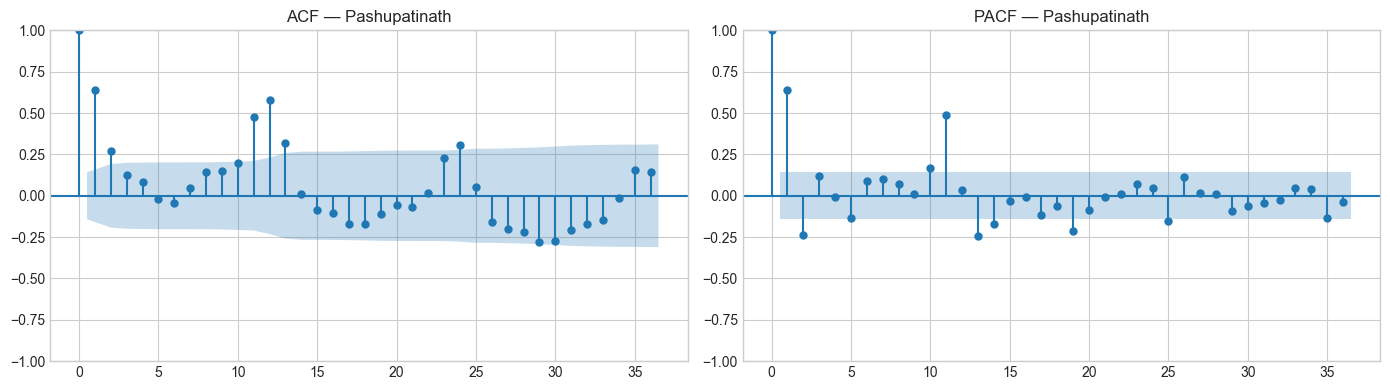

The repeating spikes at lag 12, 24, 36 confirm a 12-month seasonal pattern.
This validates our use of SARIMA with seasonal period m=12.


In [5]:
# ACF and PACF for Pashupatinath
site_data = df[df['site'] == 'Pashupatinath'].sort_values('date')
visitors = site_data['total_visitors'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ACF plot
plot_acf(visitors, lags=36, ax=axes[0], title='ACF — Pashupatinath')

# PACF plot
plot_pacf(visitors, lags=36, ax=axes[1], title='PACF — Pashupatinath', method='ywm')

plt.tight_layout()
plt.savefig('../outputs/12_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

print('The repeating spikes at lag 12, 24, 36 confirm a 12-month seasonal pattern.')
print('This validates our use of SARIMA with seasonal period m=12.')

## Step 6: Define Accuracy Metrics

We define functions to calculate MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and MAPE (Mean Absolute Percentage Error). These three metrics will be used to compare all models.

In [6]:
def calculate_metrics(actual, predicted):
    """Calculate MAE, RMSE, and MAPE"""
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    # MAPE: avoid division by zero
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    return {
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape, 2)
    }

print('Metrics function defined:')
print('  MAE  — Average size of errors (in visitor count)')
print('  RMSE — Penalises large errors more than MAE')
print('  MAPE — Error as a percentage (easier to compare across sites)')

Metrics function defined:
  MAE  — Average size of errors (in visitor count)
  RMSE — Penalises large errors more than MAE
  MAPE — Error as a percentage (easier to compare across sites)


## Step 7: Train ARIMA Models

ARIMA has three parameters: **(p, d, q)**
- **p** = number of past values used (autoregressive terms)
- **d** = number of times the data is differenced (to make it stationary)
- **q** = number of past errors used (moving average terms)

We use `order=(2, 1, 2)` as a starting point, which works well for tourism data with trends. The model is trained on 2010-2022 and tested on 2023-2025.

Janakpur Dham: MAE=9,367, RMSE=13,843, MAPE=33.73%
Lumbini: MAE=32,312, RMSE=40,439, MAPE=32.22%
Muktinath: MAE=4,210, RMSE=5,055, MAPE=54.74%
Pashupatinath: MAE=39,783, RMSE=54,127, MAPE=38.88%


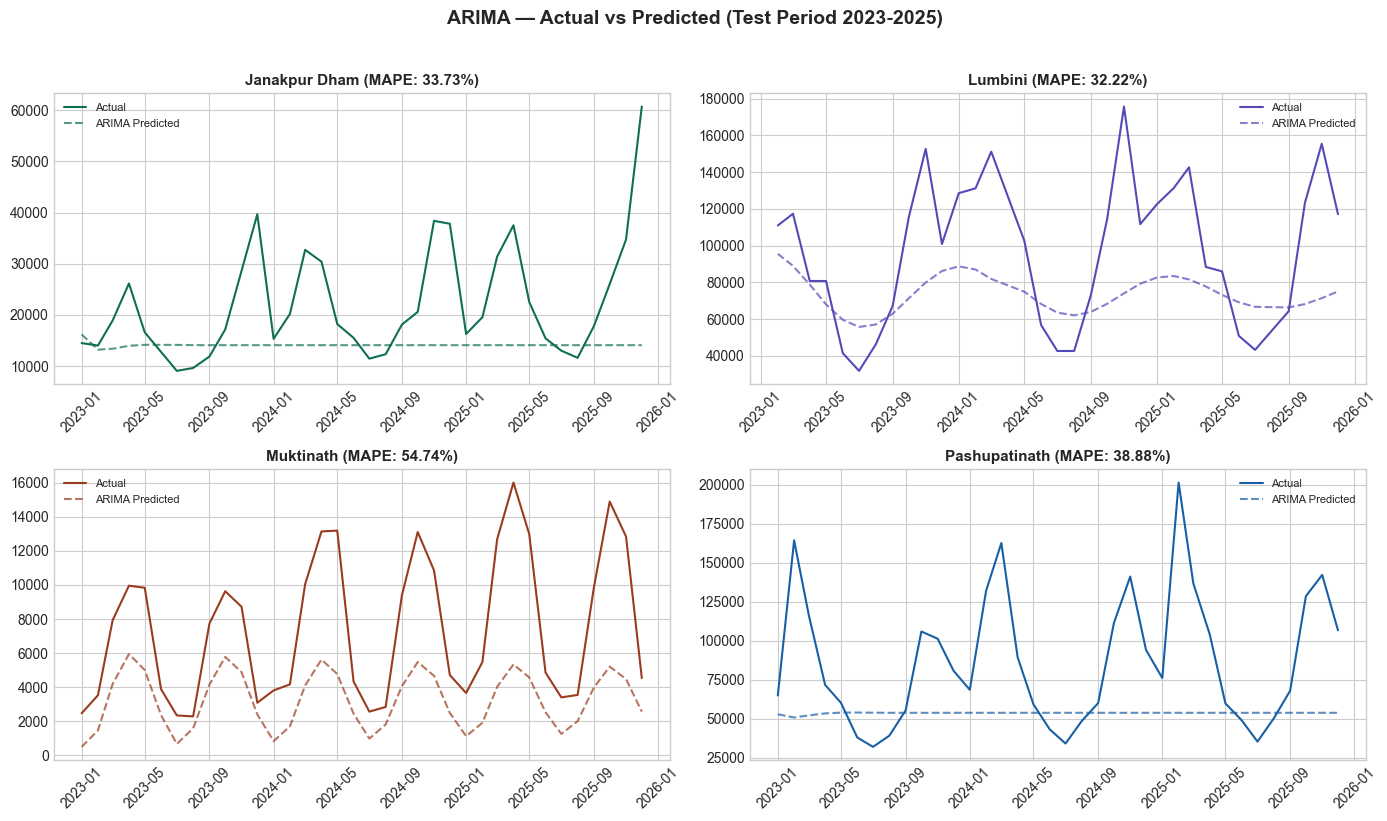


All ARIMA models trained and saved.


In [7]:
# Store results for all sites
arima_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('ARIMA — Actual vs Predicted (Test Period 2023-2025)', 
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#0F6E56', '#534AB7', '#993C1D', '#185FA5']

for i, (site, color) in enumerate(zip(sites, colors)):
    ax = axes[i // 2, i % 2]
    
    # Get site data as time series
    site_data = df[df['site'] == site].sort_values('date').set_index('date')
    ts = site_data['total_visitors']
    
    # Split into train and test
    train = ts[:TRAIN_END]
    test = ts[TEST_START:]
    
    # Train ARIMA model
    try:
        model = ARIMA(train, order=(2, 1, 2))
        fitted = model.fit()
        
        # Forecast for the test period
        forecast = fitted.forecast(steps=len(test))
        
        # Calculate metrics
        metrics = calculate_metrics(test.values, forecast.values)
        arima_results[site] = metrics
        
        # Save model
        joblib.dump(fitted, f'../models/arima_{site.lower().replace(" ", "_")}.pkl')
        
        # Plot
        ax.plot(test.index, test.values, color=color, linewidth=1.5, label='Actual')
        ax.plot(test.index, forecast.values, color=color, linewidth=1.5, 
                linestyle='--', alpha=0.7, label='ARIMA Predicted')
        ax.set_title(f'{site} (MAPE: {metrics["MAPE"]}%)', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=45)
        
        print(f'{site}: MAE={metrics["MAE"]:,.0f}, RMSE={metrics["RMSE"]:,.0f}, MAPE={metrics["MAPE"]}%')
        
    except Exception as e:
        print(f'{site}: ERROR — {e}')
        arima_results[site] = {'MAE': None, 'RMSE': None, 'MAPE': None}

plt.tight_layout()
plt.savefig('../outputs/13_arima_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll ARIMA models trained and saved.')

## Step 8: Train SARIMA Models

SARIMA extends ARIMA with seasonal parameters: **(P, D, Q, m)**
- **P** = seasonal autoregressive terms
- **D** = seasonal differencing
- **Q** = seasonal moving average terms
- **m** = seasonal period (12 for monthly data with yearly cycles)

We use `order=(1, 1, 1)` and `seasonal_order=(1, 1, 1, 12)`. The `m=12` tells the model that the pattern repeats every 12 months.

**Note:** SARIMA takes longer to train than ARIMA because it has more parameters. Each site may take 30 seconds to 2 minutes.

Training SARIMA for Janakpur Dham... (this may take a minute)
  Done! MAE=9,593, RMSE=13,495, MAPE=37.79%
Training SARIMA for Lumbini... (this may take a minute)
  Done! MAE=44,504, RMSE=57,698, MAPE=41.97%
Training SARIMA for Muktinath... (this may take a minute)
  Done! MAE=3,471, RMSE=4,356, MAPE=41.7%
Training SARIMA for Pashupatinath... (this may take a minute)
  Done! MAE=19,864, RMSE=28,305, MAPE=24.29%


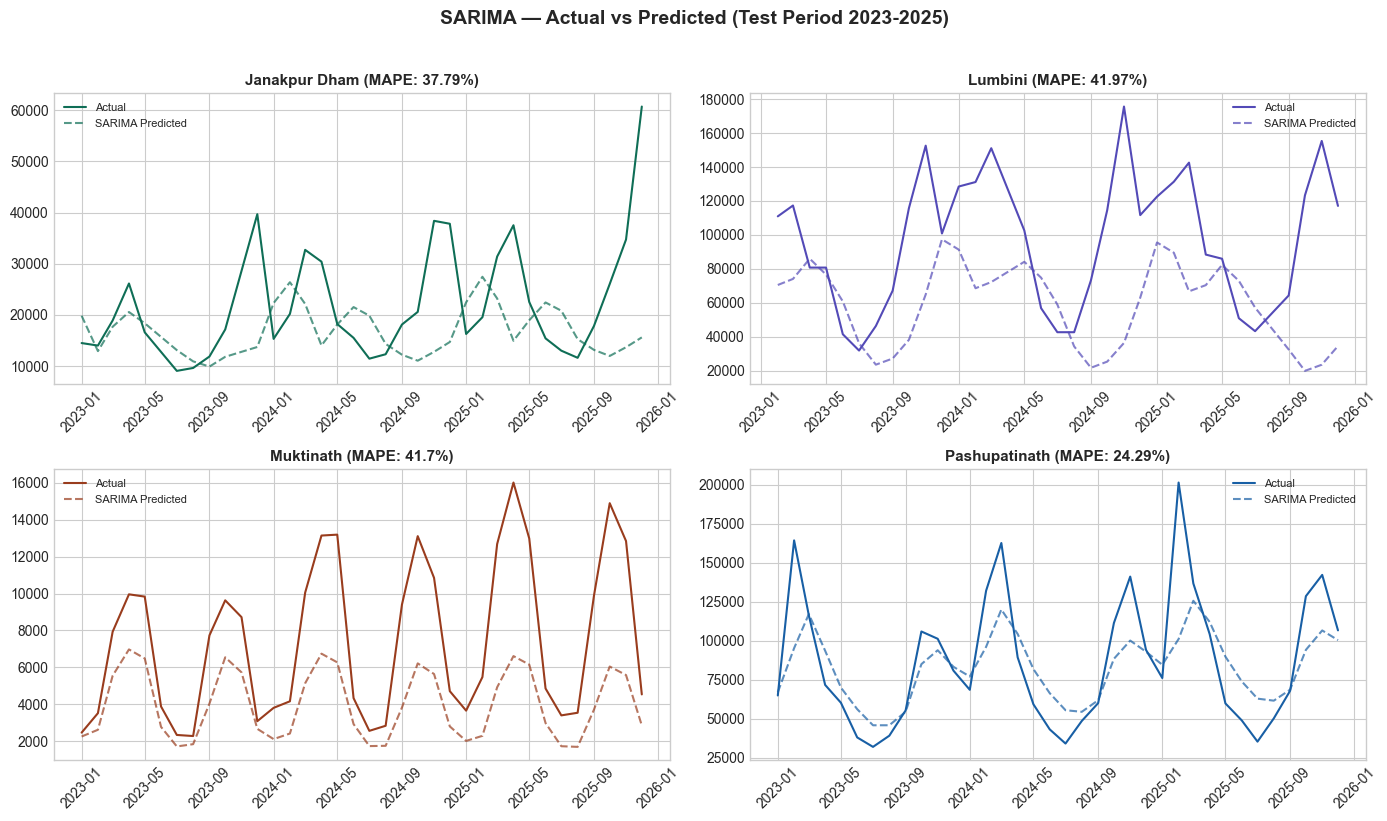


All SARIMA models trained and saved.


In [8]:
# Store results for all sites
sarima_results = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('SARIMA — Actual vs Predicted (Test Period 2023-2025)', 
             fontsize=14, fontweight='bold', y=1.02)

for i, (site, color) in enumerate(zip(sites, colors)):
    ax = axes[i // 2, i % 2]
    
    # Get site data as time series
    site_data = df[df['site'] == site].sort_values('date').set_index('date')
    ts = site_data['total_visitors']
    
    # Split into train and test
    train = ts[:TRAIN_END]
    test = ts[TEST_START:]
    
    # Train SARIMA model
    try:
        print(f'Training SARIMA for {site}... (this may take a minute)')
        
        model = SARIMAX(train, 
                        order=(1, 1, 1),                # (p, d, q)
                        seasonal_order=(1, 1, 1, 12),   # (P, D, Q, m)
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        fitted = model.fit(disp=False)  # disp=False hides training output
        
        # Forecast for the test period
        forecast = fitted.forecast(steps=len(test))
        
        # Calculate metrics
        metrics = calculate_metrics(test.values, forecast.values)
        sarima_results[site] = metrics
        
        # Save model
        joblib.dump(fitted, f'../models/sarima_{site.lower().replace(" ", "_")}.pkl')
        
        # Plot
        ax.plot(test.index, test.values, color=color, linewidth=1.5, label='Actual')
        ax.plot(test.index, forecast.values, color=color, linewidth=1.5, 
                linestyle='--', alpha=0.7, label='SARIMA Predicted')
        ax.set_title(f'{site} (MAPE: {metrics["MAPE"]}%)', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=45)
        
        print(f'  Done! MAE={metrics["MAE"]:,.0f}, RMSE={metrics["RMSE"]:,.0f}, MAPE={metrics["MAPE"]}%')
        
    except Exception as e:
        print(f'{site}: ERROR — {e}')
        sarima_results[site] = {'MAE': None, 'RMSE': None, 'MAPE': None}

plt.tight_layout()
plt.savefig('../outputs/14_sarima_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll SARIMA models trained and saved.')

## Step 9: ARIMA vs SARIMA Comparison

Now we compare the two time series models side by side. SARIMA should outperform ARIMA for sites with strong seasonal patterns because it explicitly models the 12-month cycle.

In [9]:
# Create comparison table
comparison = pd.DataFrame({
    'Site': sites,
    'ARIMA MAE': [arima_results[s]['MAE'] for s in sites],
    'SARIMA MAE': [sarima_results[s]['MAE'] for s in sites],
    'ARIMA RMSE': [arima_results[s]['RMSE'] for s in sites],
    'SARIMA RMSE': [sarima_results[s]['RMSE'] for s in sites],
    'ARIMA MAPE': [arima_results[s]['MAPE'] for s in sites],
    'SARIMA MAPE': [sarima_results[s]['MAPE'] for s in sites],
})

# Add winner column
comparison['Better Model'] = comparison.apply(
    lambda row: 'SARIMA' if row['SARIMA MAPE'] < row['ARIMA MAPE'] else 'ARIMA', axis=1
)

print('ARIMA vs SARIMA COMPARISON')
print('=' * 80)
print(comparison.to_string(index=False))
print()

# Save comparison for later use in Notebook 05
comparison.to_csv('../outputs/time_series_comparison.csv', index=False)
print('Comparison saved to: ../outputs/time_series_comparison.csv')

ARIMA vs SARIMA COMPARISON
         Site  ARIMA MAE  SARIMA MAE  ARIMA RMSE  SARIMA RMSE  ARIMA MAPE  SARIMA MAPE Better Model
Janakpur Dham    9367.02     9592.85    13843.19     13495.18       33.73        37.79        ARIMA
      Lumbini   32311.90    44503.53    40439.08     57697.65       32.22        41.97        ARIMA
    Muktinath    4209.97     3471.34     5054.58      4355.74       54.74        41.70       SARIMA
Pashupatinath   39783.17    19863.53    54126.90     28305.14       38.88        24.29       SARIMA

Comparison saved to: ../outputs/time_series_comparison.csv


## Step 10: Visual Comparison — ARIMA vs SARIMA

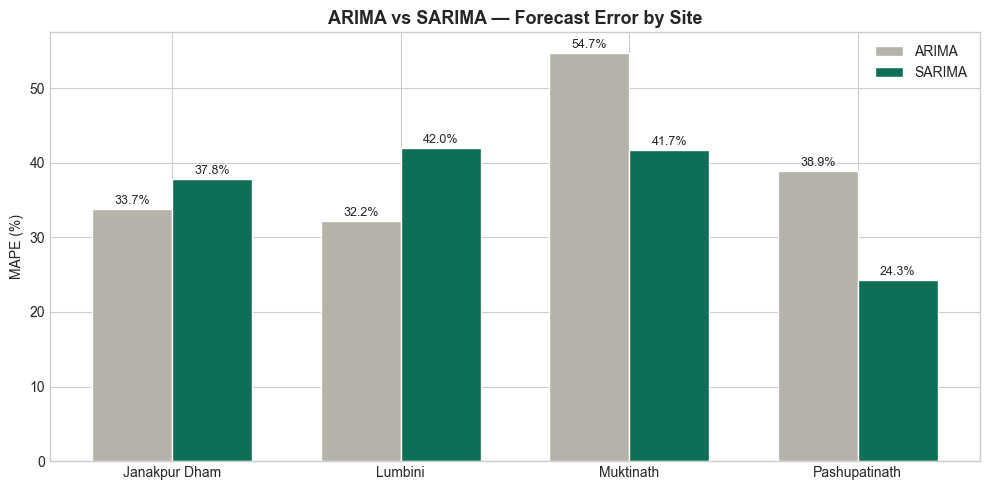

In [10]:
# Bar chart comparing MAPE for ARIMA vs SARIMA
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(sites))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['ARIMA MAPE'], width, 
               label='ARIMA', color='#B4B2A9', edgecolor='white')
bars2 = ax.bar(x + width/2, comparison['SARIMA MAPE'], width, 
               label='SARIMA', color='#0F6E56', edgecolor='white')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('MAPE (%)')
ax.set_title('ARIMA vs SARIMA — Forecast Error by Site', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sites)
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/15_arima_vs_sarima.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Full Historical Data + Future Forecast

Using the best time series model (SARIMA), we plot the complete picture: full historical data from 2010-2025 plus a 12-month forecast into 2026. This is what would appear on the Streamlit dashboard.

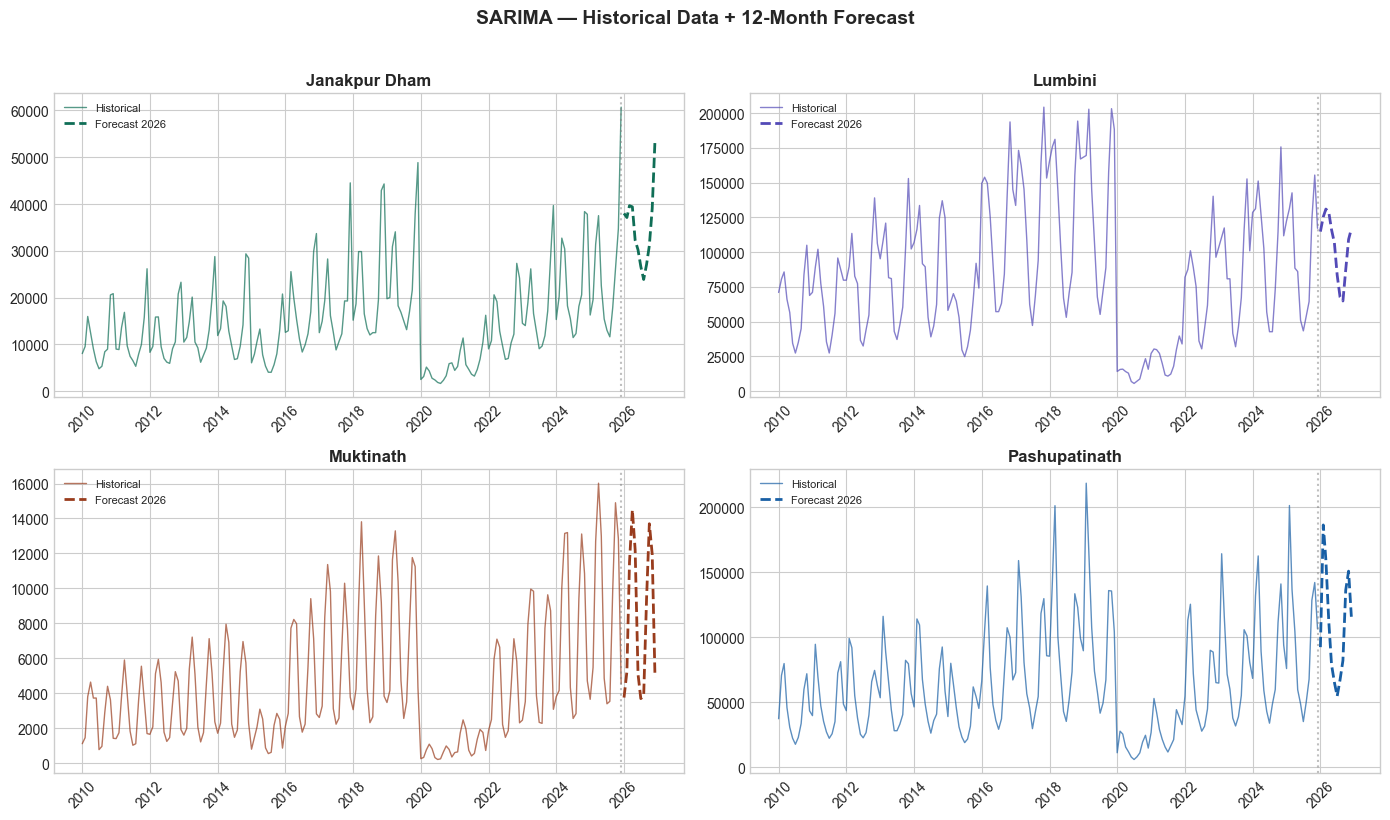

12-month forecasts generated for all four sites.


In [11]:
# Forecast 12 months ahead using SARIMA (trained on ALL data)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('SARIMA — Historical Data + 12-Month Forecast', 
             fontsize=14, fontweight='bold', y=1.02)

for i, (site, color) in enumerate(zip(sites, colors)):
    ax = axes[i // 2, i % 2]
    
    # Use ALL data for final model
    site_data = df[df['site'] == site].sort_values('date').set_index('date')
    ts = site_data['total_visitors']
    
    # Train on full data
    model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12),
                    enforce_stationarity=False, enforce_invertibility=False)
    fitted = model.fit(disp=False)
    
    # Forecast 12 months ahead
    future_dates = pd.date_range(start='2026-01', periods=12, freq='MS')
    forecast = fitted.forecast(steps=12)
    
    # Plot historical
    ax.plot(ts.index, ts.values, color=color, linewidth=1, alpha=0.7, label='Historical')
    
    # Plot forecast
    ax.plot(future_dates, forecast.values, color=color, linewidth=2, 
            linestyle='--', label='Forecast 2026')
    
    # Add divider line
    ax.axvline(x=pd.Timestamp('2025-12'), color='gray', linestyle=':', alpha=0.5)
    
    ax.set_title(site, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/16_sarima_forecast_2026.png', dpi=150, bbox_inches='tight')
plt.show()
print('12-month forecasts generated for all four sites.')

## Step 12: Save All Results

We save the accuracy metrics and model files for use in Notebook 05 (Evaluation) and the Streamlit dashboard.

In [12]:
# Save results as a dictionary for later use
all_ts_results = {
    'arima': arima_results,
    'sarima': sarima_results
}
joblib.dump(all_ts_results, '../models/time_series_results.pkl')

# List all saved model files
print('SAVED FILES:')
print('=' * 50)
for f in sorted(os.listdir('../models')):
    print(f'  ../models/{f}')

print('\n\nTIME SERIES MODELLING COMPLETE')
print('=' * 50)
print('\nARIMA Results:')
for site, metrics in arima_results.items():
    print(f'  {site}: MAPE = {metrics["MAPE"]}%')
print('\nSARIMA Results:')
for site, metrics in sarima_results.items():
    print(f'  {site}: MAPE = {metrics["MAPE"]}%')

SAVED FILES:
  ../models/arima_janakpur_dham.pkl
  ../models/arima_lumbini.pkl
  ../models/arima_muktinath.pkl
  ../models/arima_pashupatinath.pkl
  ../models/sarima_janakpur_dham.pkl
  ../models/sarima_lumbini.pkl
  ../models/sarima_muktinath.pkl
  ../models/sarima_pashupatinath.pkl
  ../models/time_series_results.pkl


TIME SERIES MODELLING COMPLETE

ARIMA Results:
  Janakpur Dham: MAPE = 33.73%
  Lumbini: MAPE = 32.22%
  Muktinath: MAPE = 54.74%
  Pashupatinath: MAPE = 38.88%

SARIMA Results:
  Janakpur Dham: MAPE = 37.79%
  Lumbini: MAPE = 41.97%
  Muktinath: MAPE = 41.7%
  Pashupatinath: MAPE = 24.29%


## Summary

### What we did:
1. Checked stationarity using ADF test
2. Examined ACF/PACF plots to confirm 12-month seasonality
3. Trained ARIMA(2,1,2) on each site — captures trends but not seasons
4. Trained SARIMA(1,1,1)(1,1,1,12) on each site — captures both trends and seasons
5. Compared ARIMA vs SARIMA using MAE, RMSE, and MAPE
6. Generated 12-month forecasts for 2026
7. Saved all models for later comparison with RF and XGBoost

### Key question for Notebook 04:
Can Random Forest and XGBoost do better by incorporating external features (weather, festivals, seasons) that ARIMA and SARIMA cannot see?

---

**Next step:** Open `04_ml_models.ipynb` to train Random Forest and XGBoost.